# h00 equation solver

This notebook implements the following:
1. Load TOV background solutions
2. Define EOS functions and unit conversion
3. Define the RHS of the second-order ODE for h00
4. Solve h00 using an RK4 integrator
5. Compute Love number k2 and Lambda
6. Plot diagnostic figures

## 1. Import required libraries

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm
import pickle
import sys
from pathlib import Path

# Add parent directory to path to import helper functions
sys.path.append(str(Path.cwd().parent))
from h00_aux import h00_approx, h00p_approx

# Configure matplotlib to use Computer Modern (math text)
plt.rcParams["mathtext.fontset"] = "cm"

## 2. Load TOV background solutions

Load precomputed TOV background solutions from `../numpy_grid/`:
- `Rgrid`: radial grid points for each stellar model
- `PMSol`: solutions for pressure P and mass M for each stellar model

In [2]:
# Load background solution (step size h = 1e-4 version)
# Rgrid: list of radial grid points, each entry is a stellar model
# PMSol: list of [M, P] solutions, each entry is a stellar model

with open("../numpy_grid/Rgrid_1e-4.pkl", "rb") as f:
    Rgrid = pickle.load(f)

with open("../numpy_grid/PMSol_1e-4.pkl", "rb") as f:
    PMSol = pickle.load(f)

print(f"Loaded {len(Rgrid)} stellar models")
print(f"Grid points in the first model: {len(Rgrid[0])}")

Loaded 25 stellar models
Grid points in the first model: 181790


## 3. Define EOS functions and unit conversion

Use n=1 polytropic EOS:
$$P = K \rho_0^2$$

Relation between energy density and pressure:
$$\rho = \frac{(1 + \sqrt{4 K P})^2 - 1}{4 K}$$

In [3]:
# Define relation between energy density and pressure (n=1 polytropic EOS)
def EnergyEOS(p, K):
    """
    Compute energy density rho given pressure p and polytropic constant K.
    
    Parameters:
        p: pressure (geometric units)
        K: polytropic constant (geometric units)
    
    Returns:
        rho: energy density (geometric units)
    """
    rr = ((1 + np.sqrt(4 * K * p))**2 - 1) / (4 * K)
    return rr

In [4]:
# Physical constants (CGS units)
G_cgs = 6.67430e-8       # gravitational constant, cm^3 g^-1 s^-2
c_cgs = 2.99792458e10    # speed of light, cm s^-1
M_sun_cgs = 1.989e33     # solar mass, g
cm2km = 1e5              # conversion factor from cm to km

def cgs_to_geom(p_cgs, n, K_cgs, eos=EnergyEOS):
    """
    Convert CGS units to geometric units (G = c = 1, length in km).
    
    Parameters:
        p_cgs: pressure (CGS units)
        n: polytropic index
        K_cgs: polytropic constant (CGS units)
        eos: energy density function
    
    Returns:
        K_geom: polytropic constant in geometric units
        p_geom: pressure in geometric units
        rho_geom: energy density in geometric units
    """
    # Convert pressure to geometric units, km^-2
    p_geom = p_cgs * G_cgs / c_cgs**4 * cm2km**2
    
    # Convert K to geometric units, km^(2/n)
    K_geom = K_cgs / G_cgs**(1/n) / c_cgs**(2-2/n) / cm2km**(2/n)
    
    # Use EOS to compute energy density, km^-2
    rho_geom = eos(p_geom, K_geom)
    
    return K_geom, p_geom, rho_geom

In [5]:
# Set parameters
K_cgs = 1.6e5            # polytropic constant (CGS units)
d_num = 25               # number of stellar models
h = 1e-4                 # integration step size

# Central pressure array: 10^33.5 to 10^36.5, total 25 models
PcArr_cgs = np.logspace(33.5, 36.5, d_num)

# Convert to geometric units
K, PcArr = cgs_to_geom(PcArr_cgs, 1, K_cgs)[:2]

print(f"K in geometric units = {K:.6e}")
print(f"Central pressure range: {PcArr[0]:.6e} to {PcArr[-1]:.6e} (geometric units)")

K in geometric units = 2.397255e+02
Central pressure range: 2.612901e-06 to 2.612901e-03 (geometric units)


## 4. Define RHS of the second-order ODE for h00

Second-order ODE satisfied by h00:
$$h_{00}'' = \frac{A(r)}{D(r)} h_{00} - B(r) h_{00}'$$

where A(r), D(r), B(r) are complex functions depending on the background solution.

In [6]:
def h00pp_rhs(r, y, p_r, rho_r, lamb_r, drho, h=1e-4):
    """
    Compute the RHS of the h00 equation.
    
    Parameters:
        r: radial coordinate
        y: state vector [h00, h00']
        p_r: pressure at this point
        rho_r: energy density at this point
        lamb_r: lambda at this point (metric function)
        drho: derivative of energy density with respect to r
        h: step size (unused, kept for interface compatibility)
    
    Returns:
        [h00', h00''] derivative vector
    """
    
    def A(r):
        """Compute coefficient A(r) in the h00 equation"""
        lamb = lamb_r
        eL = np.exp(lamb)
        e2L = eL * eL
        e3L = e2L * eL
        pr = p_r
        rr = rho_r
        rrp = drho
        pi = np.pi
        r2 = r * r
        r3 = r * r * r
        r4 = r2 * r2
        r6 = r3 * r3
        
        term = (
            -1.0 - 3.0*eL + 3.0*e2L + e3L
            + 96.0*e2L*(-5.0 + 2.0*eL)*(pi**2)*r4*(pr**2)
            + 512.0*e3L*(pi**3)*r6*(pr**3)
            - 20.0*eL*(-1.0 + eL)*pi*r2*rr
            + 4.0*eL*pi*r2*pr*(15.0 - 9.0*eL + 6.0*e2L - 40.0*eL*pi*r2*rr)
            + 8.0*eL*pi*r3*rrp
        )
        return term
    
    def denom_D(r):
        """Compute denominator D(r)"""
        eL = np.exp(lamb_r)
        return r * r * (-1.0 + eL + 8.0*eL*np.pi*(r*r)*p_r)
    
    def hp_coeff(r):
        """Compute coefficient of h00'"""
        eL = np.exp(lamb_r)
        return (1.0 + eL + 4.0*eL*np.pi*(r*r)*p_r - 4.0*eL*np.pi*(r*r)*rho_r) / r
    
    def f(r, y):
        """RHS function for the ODE"""
        y1, y2 = y  # y1 = h00, y2 = h00'
        
        D = denom_D(r)
        if D == 0.0 or not np.isfinite(D):
            raise ZeroDivisionError(f"Denominator is singular at r={r}; adjust the integration domain or background solution.")
        
        y1_src = A(r) / D
        y2_src = -hp_coeff(r)
        
        # y' = [y2, y1_src*y1 + y2_src*y2]
        return np.array([y2, y1_src*y1 + y2_src*y2], dtype=float)
    
    return f(r, y)

## 5. RK4 integrator

Use the classic fourth-order Runge-Kutta method for numerical integration.

In [7]:
def rk4_step(f, x, y, h, **kwargs):
    """
    Perform one RK4 step.
    
    Parameters:
        f: RHS function for the ODE, f(x, y, **kwargs)
        x: current independent variable
        y: current state vector
        h: step size
        **kwargs: extra parameters passed to f
    
    Returns:
        next state vector
    """
    k1 = f(x,           y,            **kwargs)
    k2 = f(x + 0.5*h,   y + 0.5*h*k1, **kwargs)
    k3 = f(x + 0.5*h,   y + 0.5*h*k2, **kwargs)
    k4 = f(x + h,       y + h*k3,     **kwargs)
    
    return y + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)

## 6. Solve the h00 equation

Solve the h00 equation for all stellar models:
1. Set initial conditions using analytic approximation
2. Integrate outward from the center using RK4
3. Save the solution for each model

In [8]:
# Store h00 solutions for all models
H00Grid = []

print(f"Start solving h00 for {d_num} stellar models...")
print(f"Step size h = {h}")
print()

for nnn in range(0, d_num):
    
    # Index of the current stellar model
    solToUseID = nnn
    PMSolArr = np.array(PMSol[solToUseID])
    
    # Extract background solution
    RArr = np.array(Rgrid[solToUseID])    # radial grid
    PArr = PMSolArr[:, 1]                  # pressure
    MArr = PMSolArr[:, 0]                  # mass
    
    # Compute energy density array
    RhoArr = EnergyEOS(PArr, K)
    
    # Compute Lambda array (metric function)
    # e^lambda = r / (r - 2M)
    LambArr = np.log(RArr / (RArr - 2*MArr))
    
    # Compute derivative of energy density w.r.t. r
    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
    
    # Central pressure of the current model
    pc = PcArr[solToUseID]
    
    # Set initial conditions using analytic series expansion
    # a0 = 1 is the normalization constant; a8 = 0 ignores higher-order terms
    h00_ini = h00_approx(r=RArr[0], K=K, pc=pc, a0=1, a8=0)
    h00p_ini = h00p_approx(r=RArr[0], K=K, pc=pc, a0=1, a8=0)
    
    # Initialize solution array
    H00ini = np.array([h00_ini, h00p_ini])
    H00Sol = np.zeros((RArr[1:].shape[0], 2))
    H00Sol[0] = H00ini
    
    # Integrate outward using RK4
    for i, r in tqdm(enumerate(RArr[1:-2]), desc=f"Model {nnn+1}/{d_num}"):
        
        # Build background parameters at this point
        params = {
            "p_r": PArr[i+1],
            "rho_r": RhoArr[i+1],
            "lamb_r": LambArr[i+1],
            "drho": DrhoArr[i]
        }
        
        # Perform one RK4 step
        H00Sol[i+1] = rk4_step(h00pp_rhs, r, H00Sol[i], h, **params)
    
    # Save solution for this model
    H00Grid.append(H00Sol)

print()
print(f"Done! Computed {len(H00Grid)} models.")

Start solving h00 for 25 stellar models...
Step size h = 0.0001



Model 1/25: 181787it [00:06, 30294.61it/s]
Model 2/25: 180088it [00:05, 31857.47it/s]
Model 3/25: 178183it [00:05, 33111.25it/s]
Model 4/25: 176057it [00:05, 32964.60it/s]
Model 5/25: 173694it [00:05, 32634.29it/s]
Model 6/25: 171082it [00:05, 30731.40it/s]
Model 7/25: 168211it [00:05, 30229.08it/s]
Model 8/25: 165072it [00:05, 29474.95it/s]
Model 9/25: 161664it [00:05, 30515.76it/s]
Model 10/25: 157989it [00:04, 32616.00it/s]
Model 11/25: 154057it [00:04, 32292.47it/s]
Model 12/25: 149884it [00:05, 28957.06it/s]
Model 13/25: 145492it [00:04, 30963.29it/s]
Model 14/25: 140911it [00:04, 32140.67it/s]
Model 15/25: 136177it [00:04, 31980.40it/s]
Model 16/25: 131331it [00:04, 31569.88it/s]
Model 17/25: 126421it [00:03, 31933.16it/s]
Model 18/25: 121494it [00:04, 24794.20it/s]
Model 19/25: 116601it [00:04, 26233.80it/s]
Model 20/25: 111792it [00:03, 30866.75it/s]
Model 21/25: 107116it [00:03, 32453.85it/s]
Model 22/25: 102621it [00:03, 28607.69it/s]
Model 23/25: 98348it [00:03, 32286.23it/s


Done! Computed 25 models.


## 7. Compute Love numbers

Compute k2 and Lambda from h00 at the stellar surface:

$$k_2 = \frac{8 C^5}{5} \frac{(1-2C^2)(2+2C(y-1)-y)}{\text{denominator}}$$

$$\Lambda = \frac{2}{3} \frac{k_2}{C^5}$$

where $y = R \cdot h_{00}'(R) / h_{00}(R)$ is the logarithmic derivative.

In [9]:
def K2(C, R, hR, DhR):
    """
    Compute Love number k2.
    
    Parameters:
        C: compactness = M/R
        R: stellar radius
        hR: h00 value at the stellar surface
        DhR: h00' value at the stellar surface
    
    Returns:
        k2: Love number
    """
    # Compute logarithmic derivative y = R * h00'(R) / h00(R)
    y = R * DhR / hR
    
    # Numerator of the k2 formula
    term0 = (8/5) * (C**5) * (1 - 2*(C**2)) * (2 + 2*C*(y-1) - y)
    
    # Terms in the denominator of the k2 formula
    term1 = 2*C * (6 - 3*y + 3*C*(5*y - 8))
    term2 = 4*(C**3) * (13 - 11*y + C*(3*y - 2) + 2*(C**2)*(1 + y))
    term3 = 3*(1 - 2*C)**2 * (2 - y + 2*C*(y - 1)) * np.log(1 - 2*C)
    
    return term0 / (term1 + term2 + term3)


def Love(k2, C):
    """
    Compute the dimensionless tidal Love number Lambda.
    
    Parameters:
        k2: Love number
        C: compactness
    
    Returns:
        Lambda: dimensionless tidal Love number
    """
    return (2/3) * k2 / (C**5)

In [10]:
# Extract h00 and h00' at the stellar surface
H00R = np.array([H00Grid[i][-2, 0] for i in range(d_num)])    # h00(R)
DH00R = np.array([H00Grid[i][-2, 1] for i in range(d_num)])   # h00'(R)
RstarArr = np.array([rarr[-2] for rarr in Rgrid])              # stellar radius

# Compute compactness C = M/R
C = np.array([mparr[-2] for mparr, rarr in zip(PMSol, Rgrid)])
CompactnessArr = C[:, 0] / np.array([rarr[-2] for rarr in Rgrid])

# Compute k2 and Lambda
K2Arr = K2(CompactnessArr, RstarArr, H00R, DH00R)
LoveArr = Love(K2Arr, CompactnessArr)

print("Results:")
print(f"Compactness range: {CompactnessArr.min():.4f} to {CompactnessArr.max():.4f}")
print(f"k2 range: {K2Arr.min():.4e} to {K2Arr.max():.4e}")
print(f"Lambda range: {LoveArr.min():.2f} to {LoveArr.max():.2e}")

Results:
Compactness range: 0.0438 to 0.2479
k2 range: 4.2796e-02 to 2.2509e-01
Lambda range: 30.49 to 9.27e+05


## 8. Plot results

### 8.1 h00(R) and h00'(R) vs R

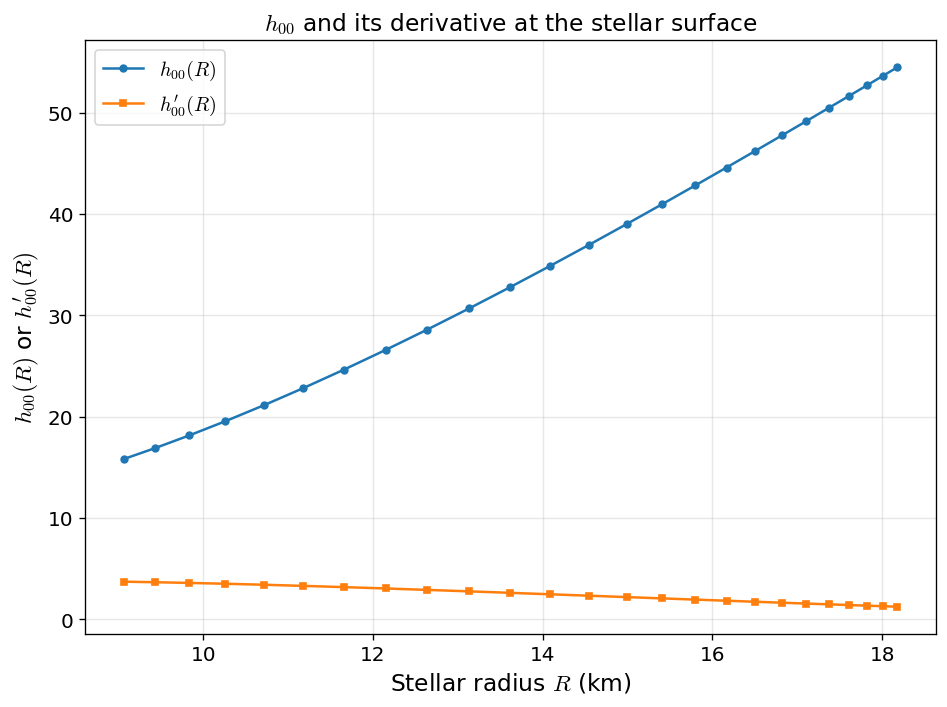

In [11]:
# Plot h00(R) and h00'(R) versus stellar radius
plt.figure(figsize=(8, 6), dpi=120)

plt.plot(RstarArr, H00R, 'o-', label=r"$h_{00}(R)$", markersize=4)
plt.plot(RstarArr, DH00R, 's-', label=r"$h_{00}'(R)$", markersize=4)

plt.xlabel(r"Stellar radius $R$ (km)", fontsize=14)
plt.ylabel(r"$h_{00}(R)$ or $h_{00}'(R)$", fontsize=14)
plt.title(r"$h_{00}$ and its derivative at the stellar surface", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

### 8.2 Compactness vs Tidal Love Number (comparison with 1608.02582)

In [12]:
def CompactPRD(k2, a=[0.371, -0.0391, 0.001056]):
    """
    Fitting formula from 1608.02582.
    Given Lambda, compute the corresponding compactness C.
    
    Parameters:
        k2: Tidal Love Number Lambda
        a: fit coefficient
    
    Returns:
        C: compactness
    """
    lnk2 = np.log(k2)
    Compactness = a[0] + a[1]*lnk2 + a[2]*(lnk2**2)
    return Compactness

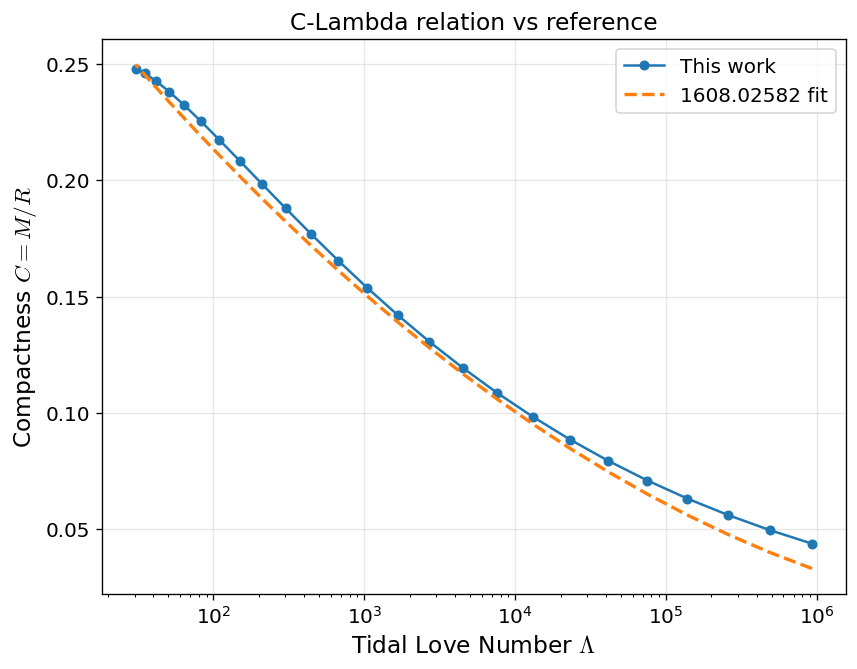

In [13]:
# Plot compactness vs tidal Love number, compare with the reference
plt.figure(figsize=(8, 6), dpi=120)

plt.plot(LoveArr, CompactnessArr, 'o-', label="This work", markersize=5, linewidth=1.5)
plt.plot(LoveArr, CompactPRD(LoveArr), '--', label="1608.02582 fit", linewidth=2)

plt.xscale("log")
plt.xlabel(r"Tidal Love Number $\Lambda$", fontsize=14)
plt.ylabel(r"Compactness $C = M/R$", fontsize=14)
plt.title("C-Lambda relation vs reference", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# plt.tight_layout()
plt.show()

### 8.3 h00/r^2 vs r

Check h00 behavior. Since h00 ~ r^2 at small r, h00/r^2 should be constant near the center.

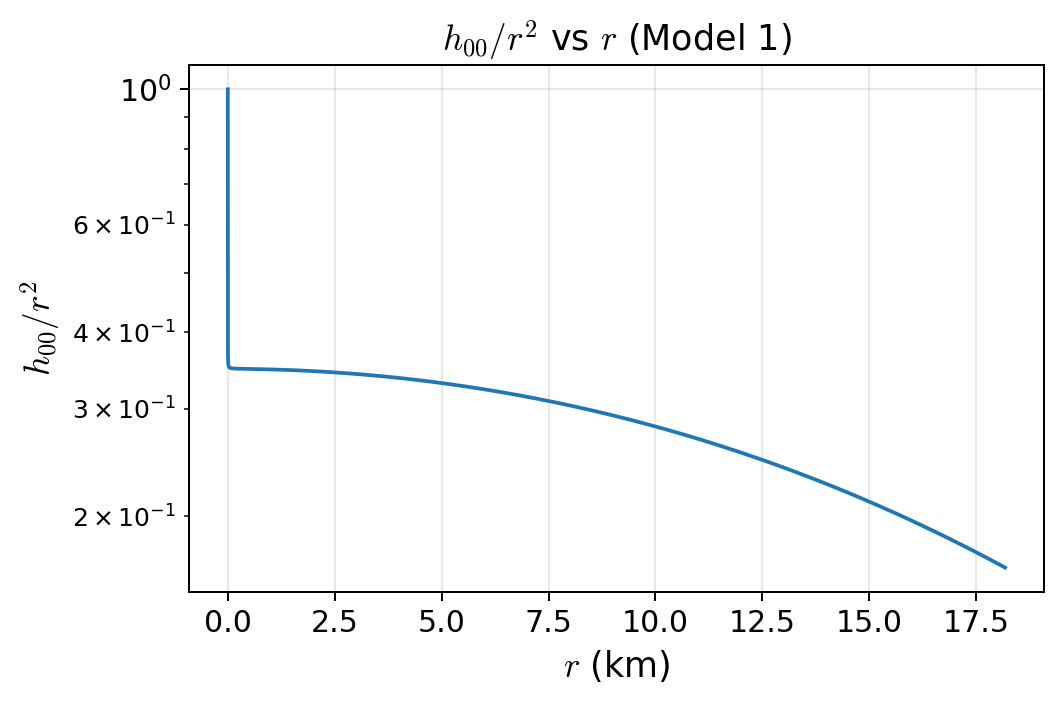

In [14]:
# Plot h00/r^2 for the first model
model_idx = 0
RArr_plot = np.array(Rgrid[model_idx])[:-5]
H00_plot = H00Grid[model_idx][:-4, 0]

plt.figure(figsize=(6, 4), dpi=180)

plt.plot(RArr_plot, H00_plot / np.power(RArr_plot, 2))

plt.yscale("log")
plt.xlabel(r"$r$ (km)", fontsize=14)
plt.ylabel(r"$h_{00}/r^2$", fontsize=14)
plt.title(rf"$h_{{00}}/r^2$ vs $r$ (Model {model_idx + 1})", fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## 9. Alternative solve for u = h00/r^2 (validation)

To validate the results, we also solve the ODE for u = h00/r^2.

In [15]:
def u_pp_rhs(r, Y, p_r, rho_r, lamb_r, drho):
    """
    RHS of the ODE satisfied by u = h00/r^2.
    
    Parameters:
        r: radial coordinate
        Y: state vector [u, u']
        p_r: pressure at this point
        rho_r: energy density at this point
        lamb_r: lambda at this point
        drho: derivative of energy density with respect to r
    
    Returns:
        [u', u''] derivative vector
    """
    u, up = Y
    pi = np.pi
    
    eL = np.exp(lamb_r)
    e2L = eL * eL
    e3L = e2L * eL
    
    r2 = r * r
    r3 = r2 * r
    r4 = r2 * r2
    r6 = r3 * r3
    
    # A(r) coefficient
    A = (
        -1.0 - 3.0*eL + 3.0*e2L + e3L
        + 96.0*e2L*(-5.0 + 2.0*eL)*(pi**2)*r4*(p_r**2)
        + 512.0*e3L*(pi**3)*r6*(p_r**3)
        - 20.0*eL*(-1.0 + eL)*pi*r2*rho_r
        + 4.0*eL*pi*r2*p_r*(15.0 - 9.0*eL + 6.0*e2L - 40.0*eL*pi*r2*rho_r)
        + 8.0*eL*pi*r3*drho
    )
    
    # D(r) denominator
    D = r2 * (-1.0 + eL + 8.0*eL*pi*r2*p_r)
    if D == 0.0 or not np.isfinite(D):
        raise ZeroDivisionError(f"Denominator is singular at r={r}")
    
    # B(r) coefficient
    B = 1.0 + eL + 4.0*eL*pi*r2*p_r - 4.0*eL*pi*r2*rho_r
    
    # Expression for u''
    upp = (A/D)*u - ((4.0 + B)/r)*up - ((2.0 + 2.0*B)/r2)*u
    
    return np.array([up, upp], dtype=float)

In [41]:
# Solve the u equation (select a few models for validation)
UGrid = []
test_models = np.arange(0,25)  # test model indices

print(f"Solve u = h00/r^2 for validation...")

for nnn in test_models:
    
    solToUseID = nnn
    PMSolArr = np.array(PMSol[solToUseID])
    
    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:, 1]
    MArr = PMSolArr[:, 0]
    
    # Background arrays
    RhoArr = EnergyEOS(PArr, K)
    LambArr = np.log(RArr / (RArr - 2.0*MArr))
    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
    
    pc = PcArr[solToUseID]
    
    # Initial conditions
    r0 = RArr[0]
    h0 = h00_approx(r=r0, K=K, pc=pc, a0=1, a8=0)
    hp0 = h00p_approx(r=r0, K=K, pc=pc, a0=1, a8=0)
    
    u0 = h0 / (r0**2)
    up0 = (r0*hp0 - 2.0*h0) / (r0**3)
    
    USol = np.zeros((RArr.shape[0], 2), dtype=float)
    USol[0] = np.array([u0, up0], dtype=float)
    
    # Integrate with adaptive step size
    for i, r in tqdm(enumerate(RArr[:-1]), total=len(RArr)-1, desc=f"Model {nnn+1}"):
        
        dr = RArr[i+1] - RArr[i]
        
        params = {
            "p_r": PArr[i],
            "rho_r": RhoArr[i],
            "lamb_r": LambArr[i],
            "drho": DrhoArr[i],
        }
        
        USol[i+1] = rk4_step(u_pp_rhs, r, USol[i], dr, **params)
    
    UGrid.append(USol)

print("Validation complete!")

Solve u = h00/r^2 for validation...


Model 25: 100%|██████████| 90632/90632 [00:02<00:00, 40121.69it/s]

Validation complete!


### 9.1 Comparison of numerical u with analytic approximation

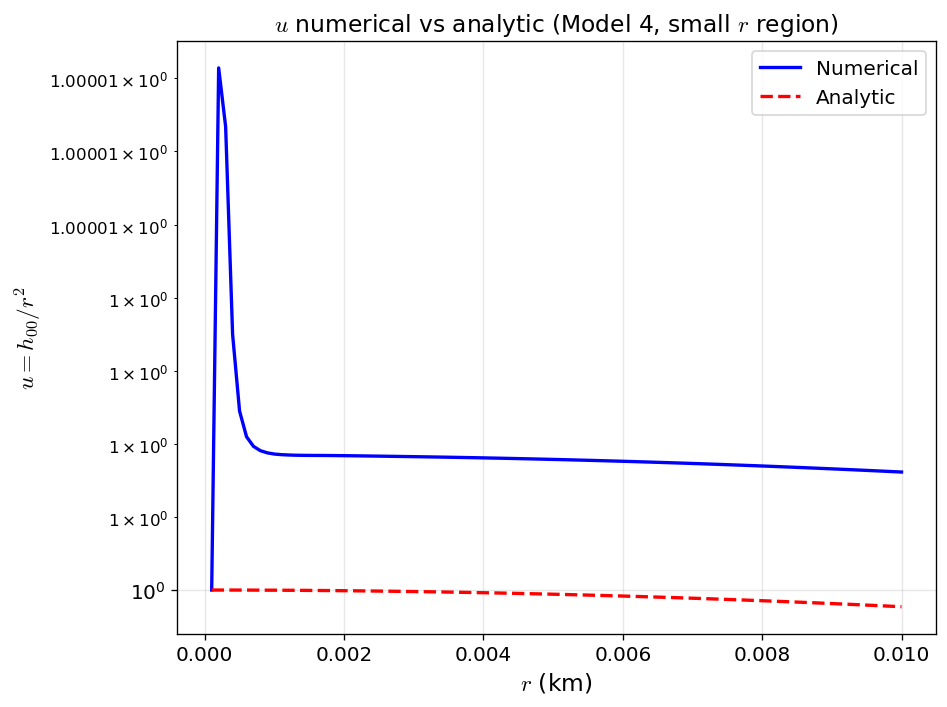

In [17]:
# Plot numerical u vs analytic approximation (small r region)
model_idx = 0  # first model in UGrid corresponds to test_models[0]
actual_model_idx = test_models[model_idx]

RArr = np.array(Rgrid[actual_model_idx])
pc = PcArr[actual_model_idx]

# Analytic approximation
u_analytic = h00_approx(r=RArr[:100], K=K, pc=pc, a0=1, a8=0) / RArr[:100]**2

plt.figure(figsize=(8, 6), dpi=120)

plt.plot(RArr[:100], UGrid[model_idx][:100, 0], 'b-', label="Numerical", linewidth=2)
plt.plot(RArr[:100], u_analytic, 'r--', label="Analytic", linewidth=2)

plt.yscale("log")
plt.xlabel(r"$r$ (km)", fontsize=14)
plt.ylabel(r"$u = h_{00}/r^2$", fontsize=14)
plt.title(rf"$u$ numerical vs analytic (Model {actual_model_idx + 1}, small $r$ region)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

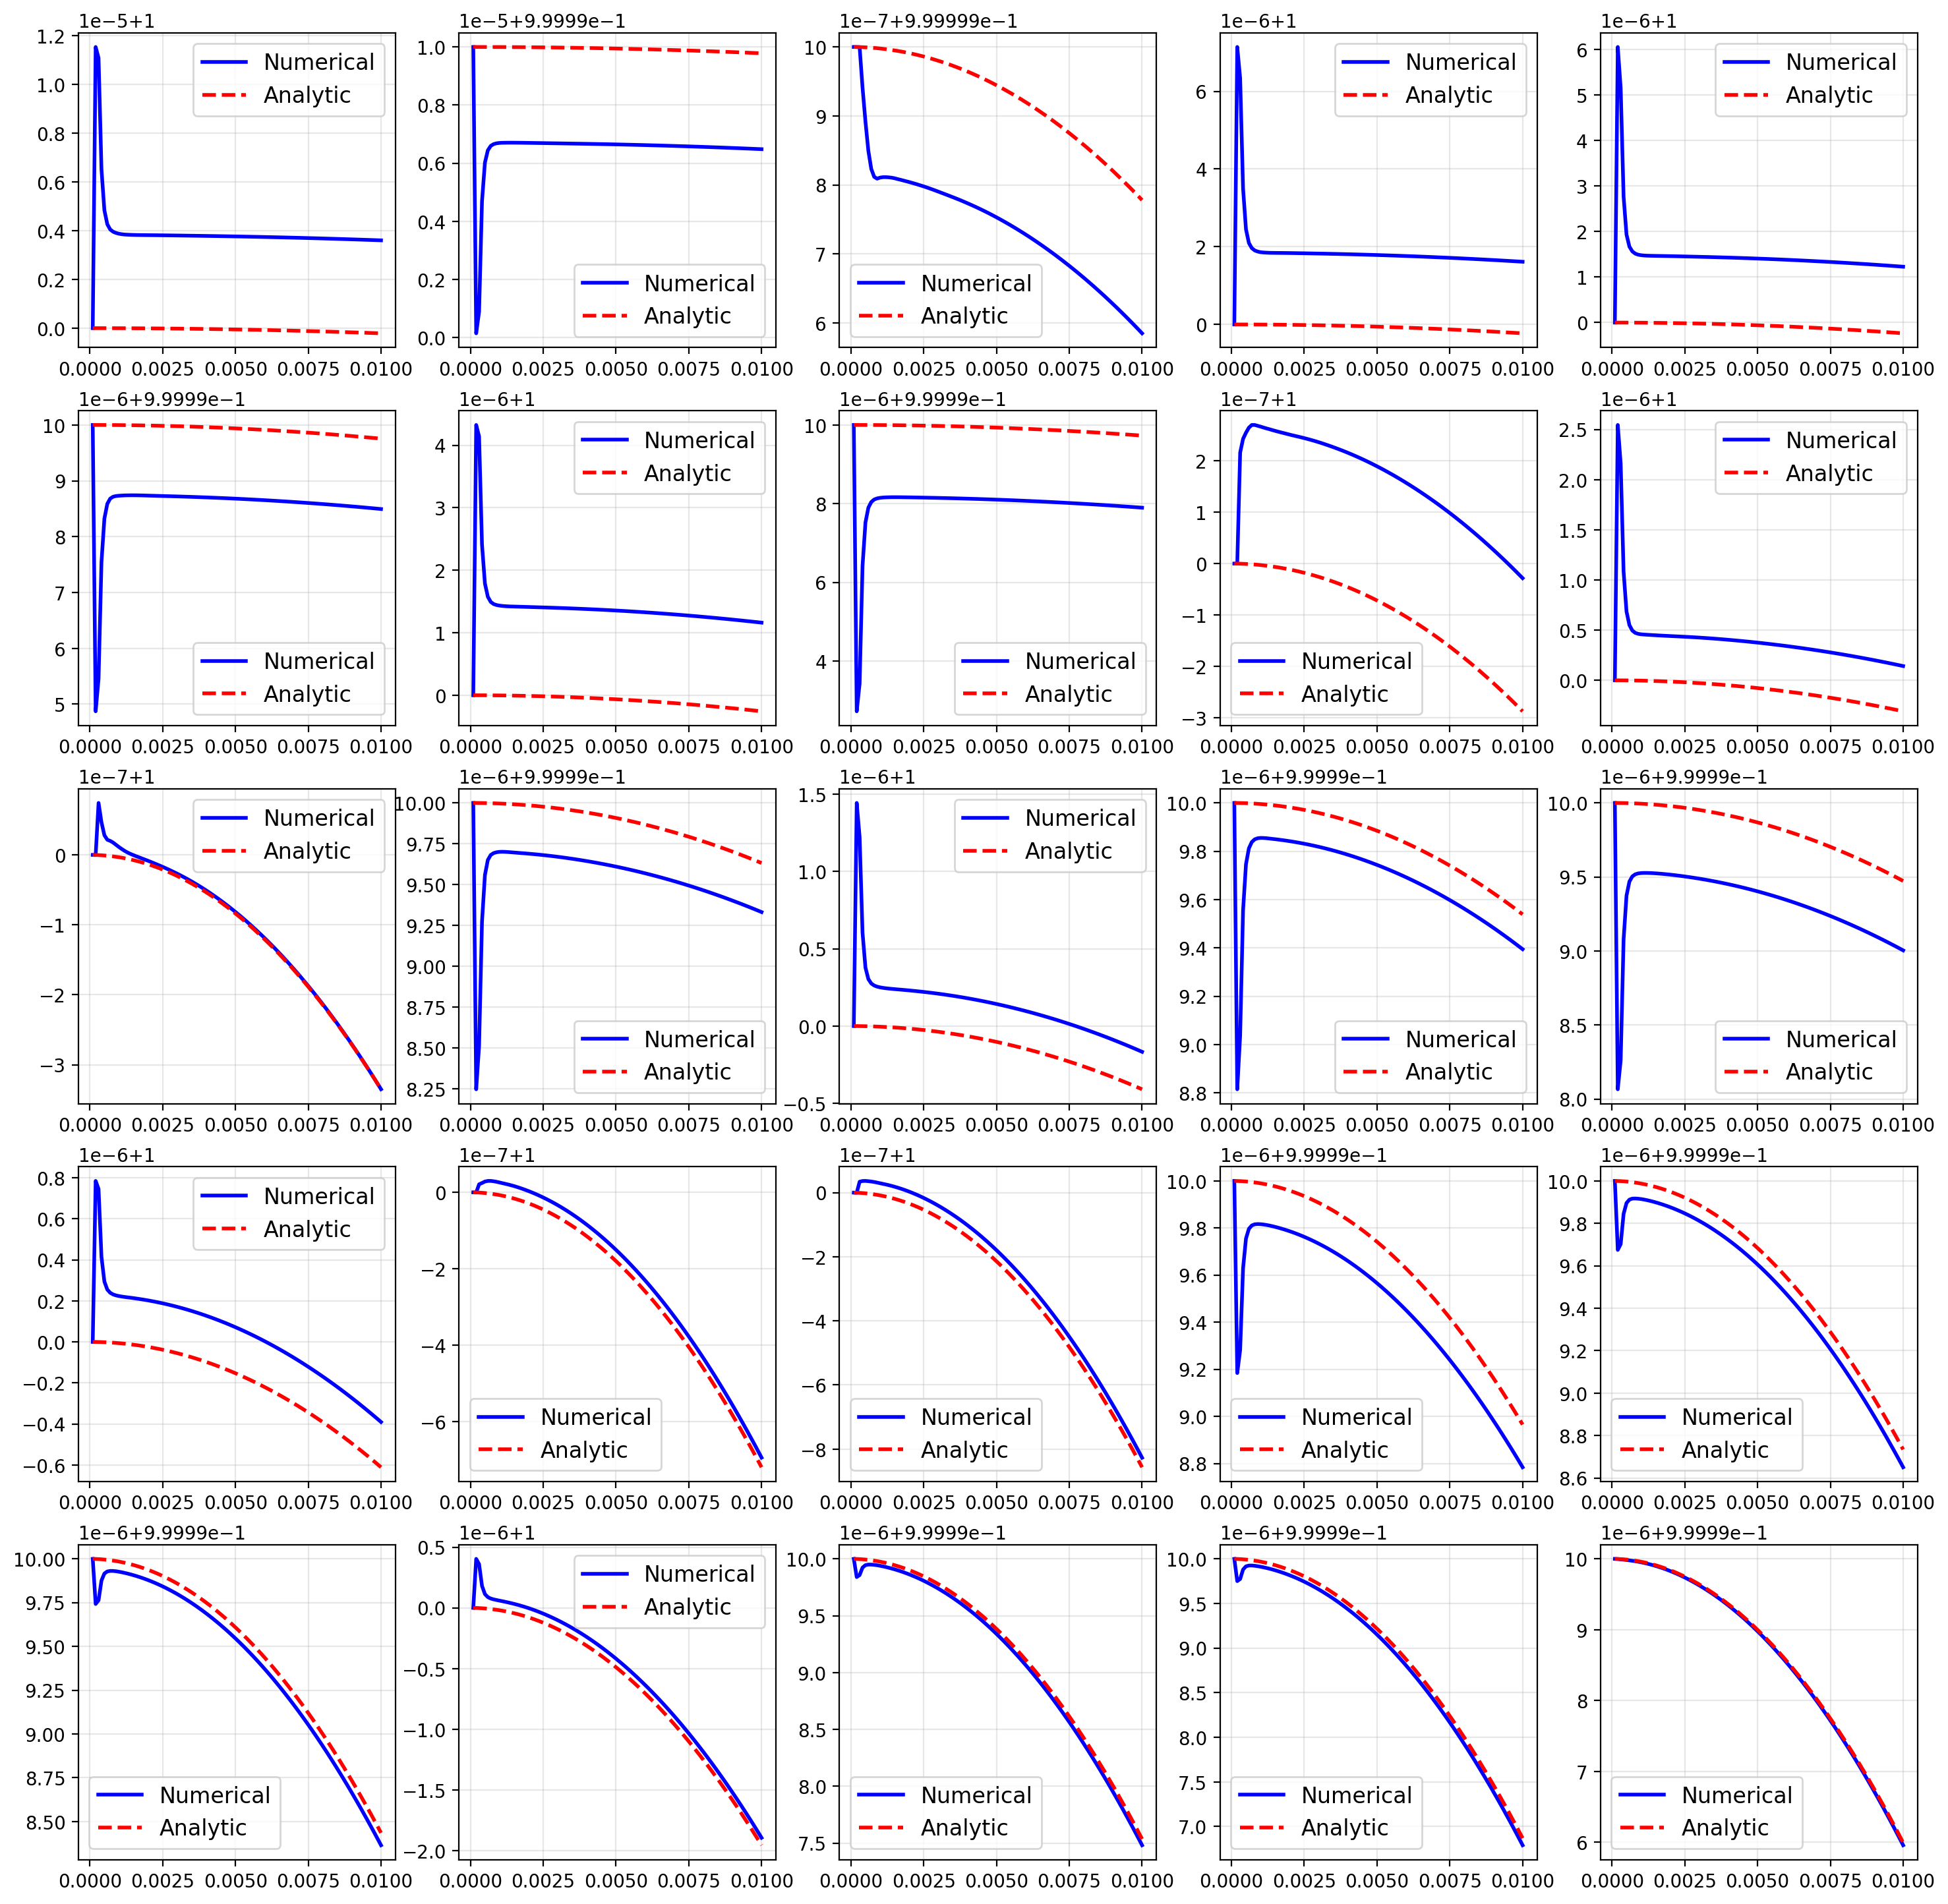

In [57]:
fig, ax = plt.subplots(5, 5, figsize = (18,18), dpi = 200)

for nn in range(0,25):

    model_idx = nn  # going through all stars

    RArr = np.array(Rgrid[model_idx])
    pc = PcArr[model_idx]

    # Analytic approximation
    u_analytic = h00_approx(r=RArr[:100], K=K, pc=pc, a0=1, a8=0) / RArr[:100]**2

    ax[nn // 5][nn % 5].plot(RArr[:100], UGrid[model_idx][:100, 0], 'b-', label="Numerical", linewidth=2)
    ax[nn // 5][nn % 5].plot(RArr[:100], u_analytic, 'r--', label="Analytic", linewidth=2)

    # ax[nn // 5][nn % 5].set_yscale("log")
    # ax[nn // 5][nn % 5].set_xlabel(r"$r$ (km)", fontsize=14)
    # ax[nn // 5][nn % 5].set_ylabel(r"$u = h_{00}/r^2$", fontsize=14)
    # ax[nn // 5][nn % 5].set_title(rf"$u$ numerical vs analytic (Model {model_idx + 1}, small $r$ region)", fontsize=14)
    ax[nn // 5][nn % 5].legend(fontsize=12)
    ax[nn // 5][nn % 5].grid(alpha=0.3)
    # ax[nn // 5][nn % 5].set_xticks(fontsize=12)
    # ax[nn // 5][nn % 5].set_yticks(fontsize=12)

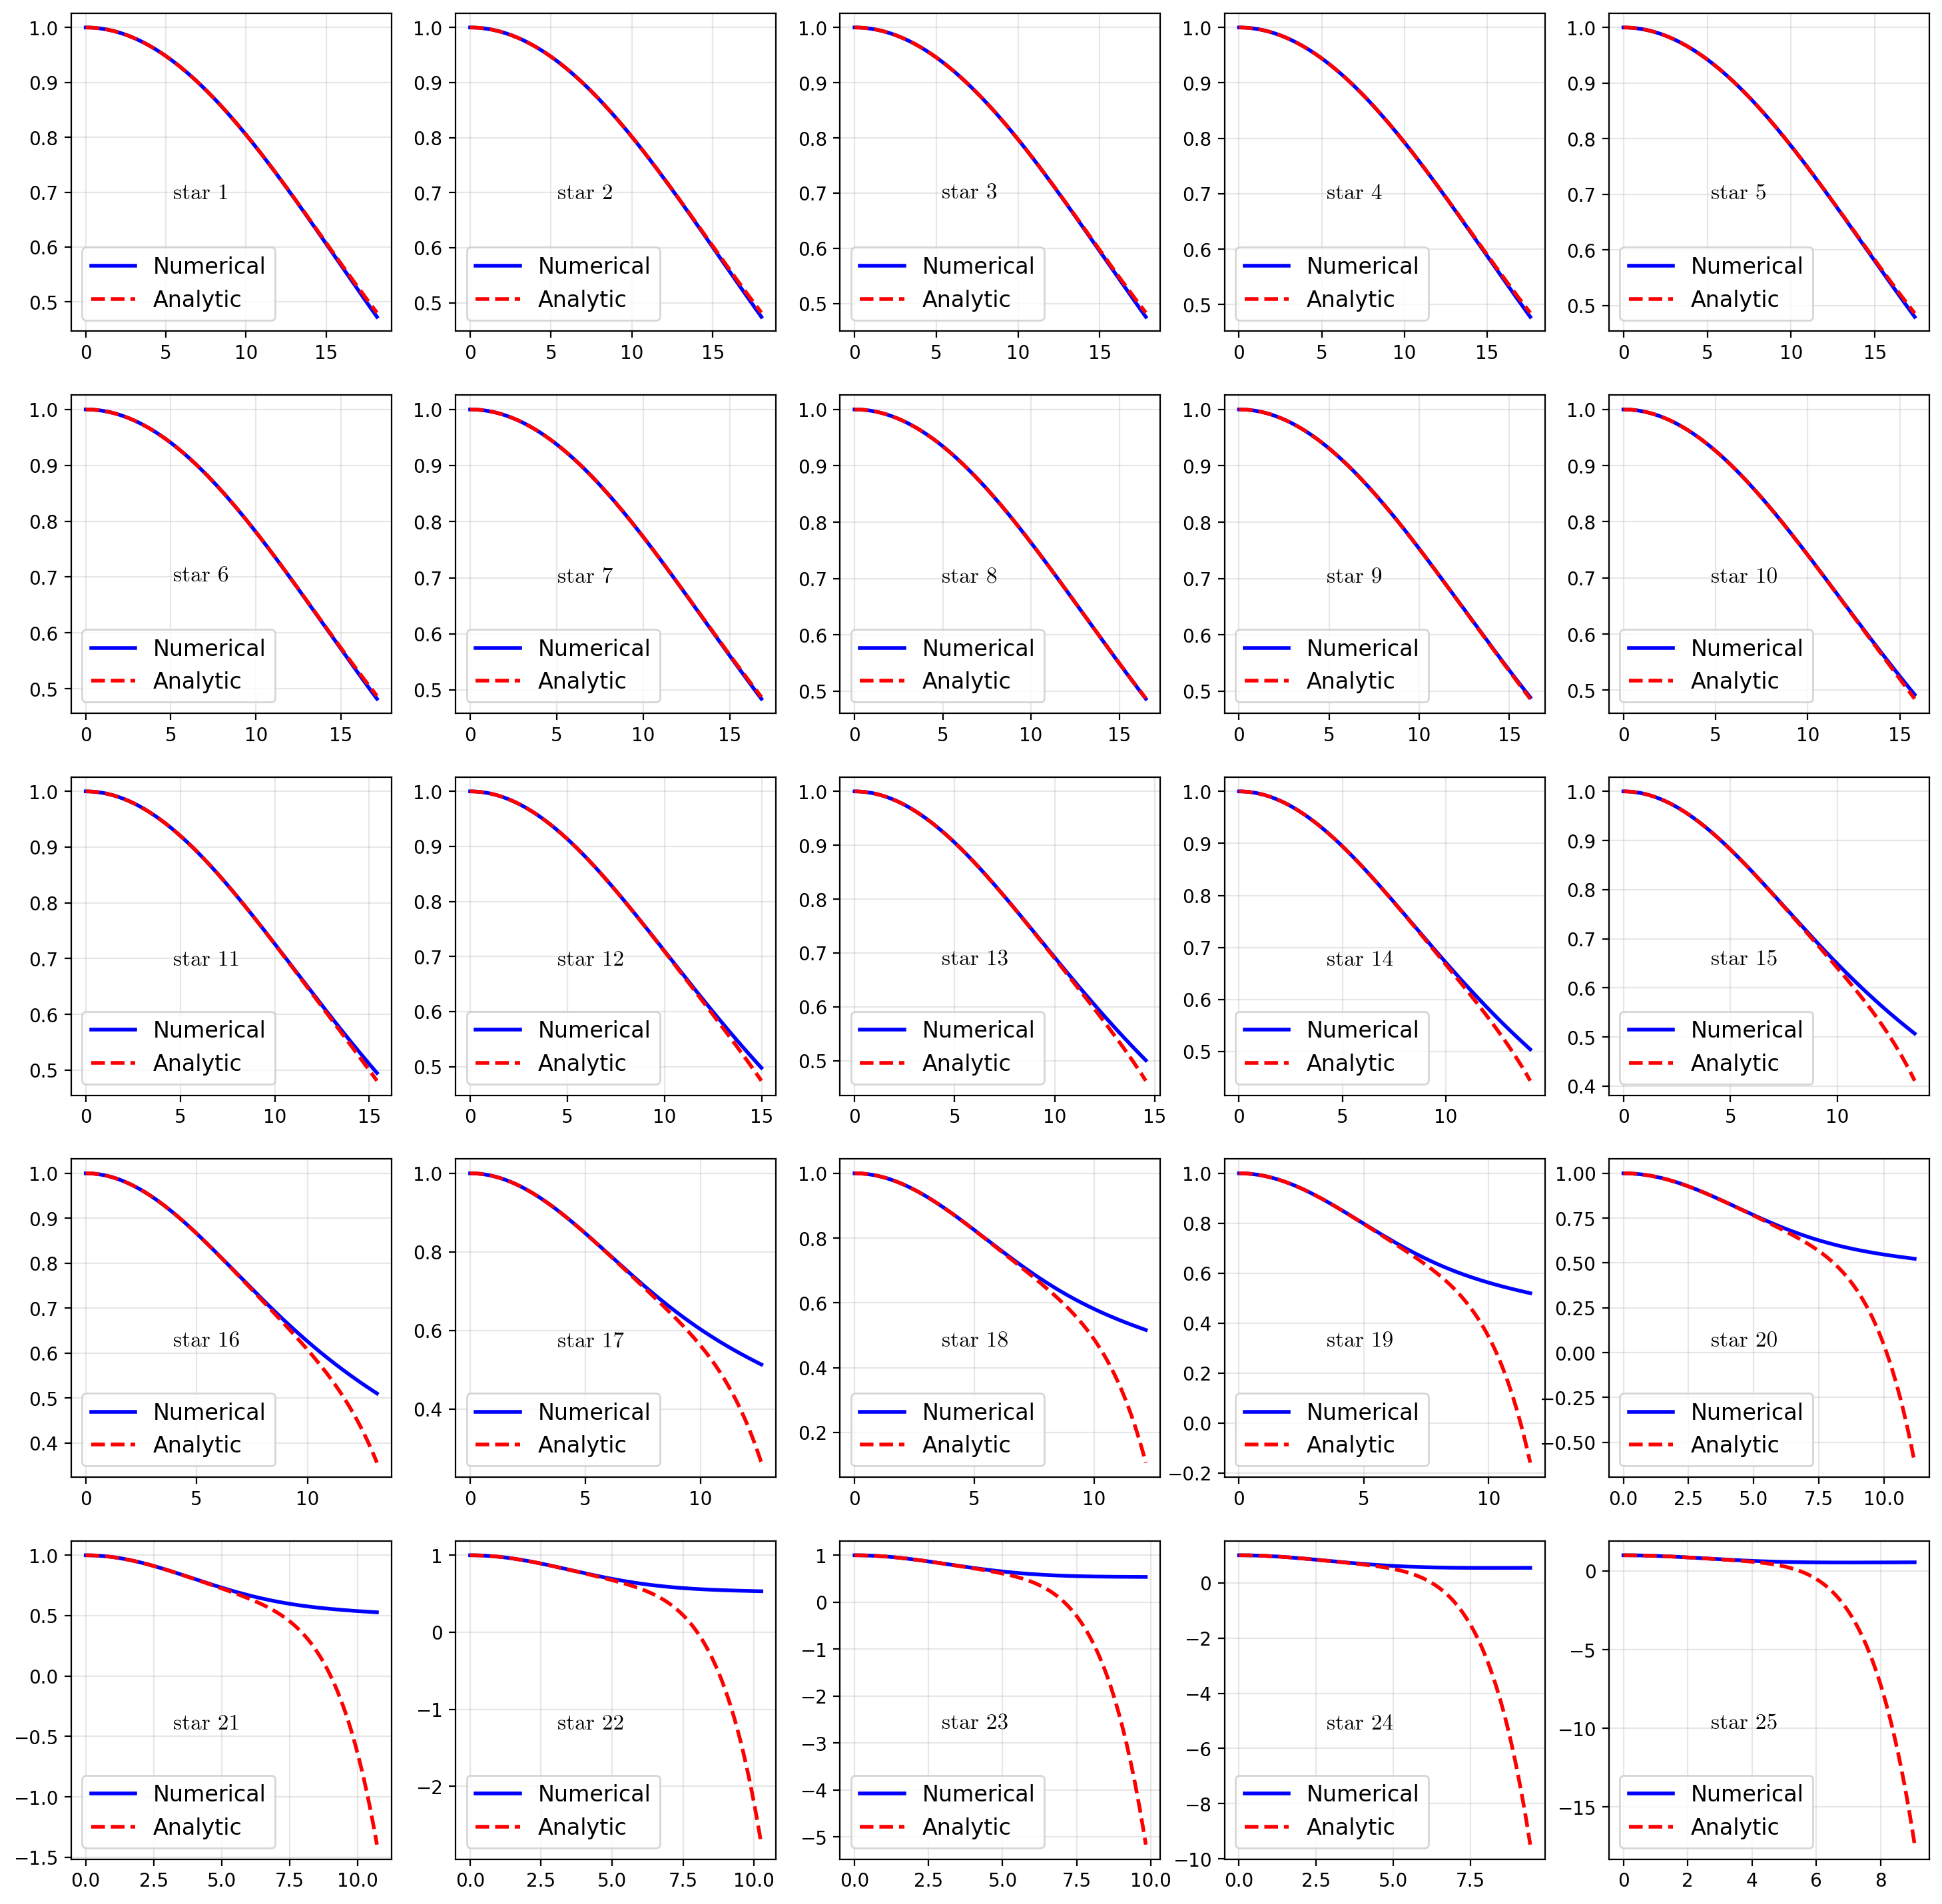

In [ ]:

fig, ax = plt.subplots(5, 5, figsize = (18,18), dpi = 200)

for nn in range(0,25):

    model_idx = nn

    RArr = np.array(Rgrid[model_idx])
    pc = PcArr[model_idx]
        
    # Plot numerical u vs analytic approximation (full range)
    u_analytic_full = h00_approx(r=RArr, K=K, pc=pc, a0=1, a8=0) / RArr**2

    ax[nn // 5][nn % 5].plot(RArr, UGrid[model_idx][:, 0], 'b-', label="Numerical", linewidth=2)
    ax[nn // 5][nn % 5].plot(RArr, u_analytic_full, 'r--', label="Analytic", linewidth=2)

    # ax[nn // 5][nn % 5].xlabel(r"$r$ (km)", fontsize=14)
    # ax[nn // 5][nn % 5].ylabel(r"$u = h_{00}/r^2$", fontsize=14)
    ax[nn // 5][nn % 5].text(x = RArr[-1] * 0.3, y = 1 - 0.6*(1 - u_analytic_full[-1]),  s=f"star {nn + 1}", fontsize=12,fontfamily="CMU Serif")
    ax[nn // 5][nn % 5].legend(fontsize=12)
    ax[nn // 5][nn % 5].grid(alpha=0.3)



### 9.2 u residuals

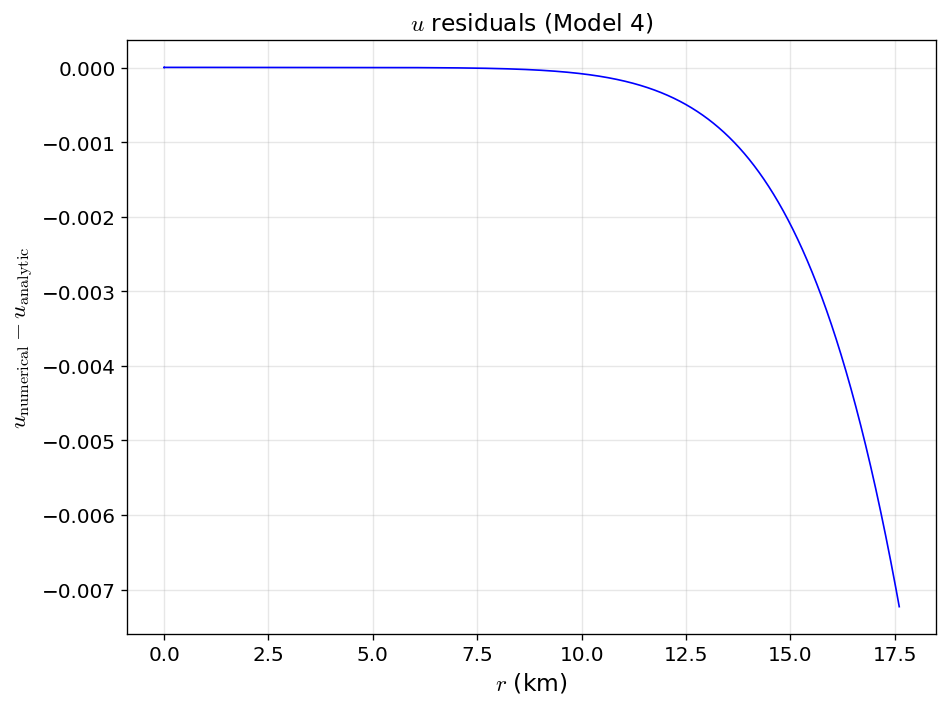

In [19]:
# Plot u residuals (numerical - analytic)
residual = UGrid[model_idx][:, 0] - u_analytic_full

plt.figure(figsize=(8, 6), dpi=120)

plt.plot(RArr, residual, 'b-', linewidth=1)

plt.xlabel(r"$r$ (km)", fontsize=14)
plt.ylabel(r"$u_{\mathrm{numerical}} - u_{\mathrm{analytic}}$", fontsize=14)
plt.title(rf"$u$ residuals (Model {actual_model_idx + 1})", fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.tight_layout()
plt.show()

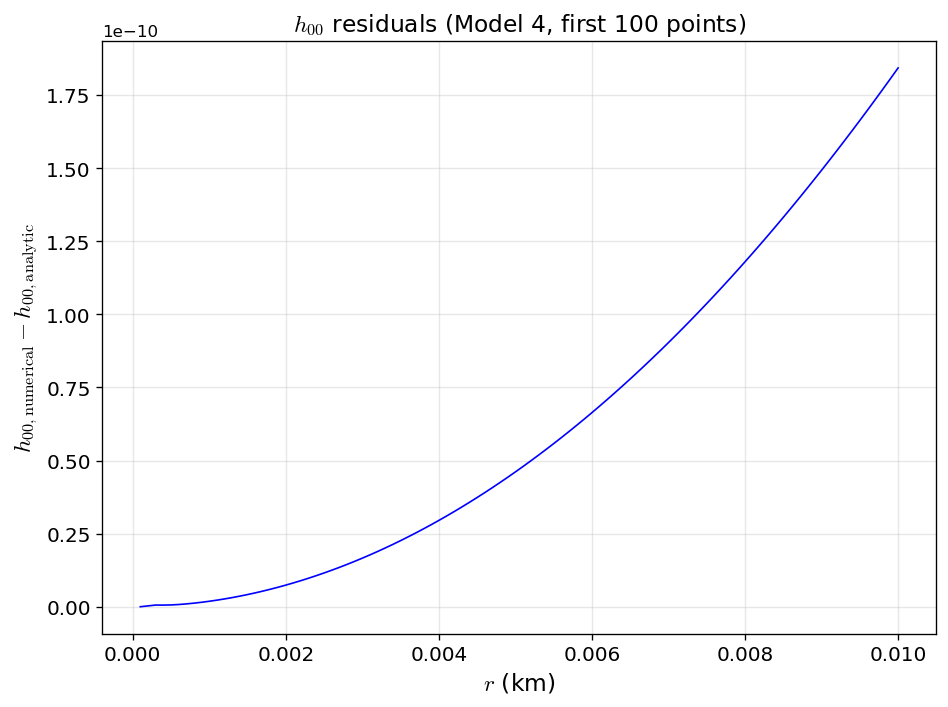

h00 residual statistics for the first 100 points:
  Max absolute residual: 1.842375e-10
  Mean absolute residual: 6.237666e-11


In [20]:
# Plot h00 residuals (compare u*r^2 with analytic h00)
h00_from_u = UGrid[model_idx][:, 0] * RArr**2
h00_analytic = h00_approx(r=RArr, K=K, pc=pc, a0=1, a8=0)
h00_residual = h00_from_u - h00_analytic

# Show only the first 100 points
plt.figure(figsize=(8, 6), dpi=120)

plt.plot(RArr[:100], h00_residual[:100], 'b-', linewidth=1)

plt.xlabel(r"$r$ (km)", fontsize=14)
plt.ylabel(r"$h_{00,\mathrm{numerical}} - h_{00,\mathrm{analytic}}$", fontsize=14)
plt.title(rf"$h_{{00}}$ residuals (Model {actual_model_idx + 1}, first 100 points)", fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# Print residual statistics
print(f"h00 residual statistics for the first 100 points:")
print(f"  Max absolute residual: {np.max(np.abs(h00_residual[:100])):.6e}")
print(f"  Mean absolute residual: {np.mean(np.abs(h00_residual[:100])):.6e}")

## 10. Summary

This notebook completed the following:
1. Loaded TOV background solutions
2. Defined EOS functions and unit conversion
3. Solved the h00 equation (for all 25 stellar models)
4. Computed Love number k2 and Lambda
5. Compared with reference 1608.02582
6. Validated by solving u = h00/r^2